# Exploratory Data Analysis (EDA)
## Dataset: loan_data_2007_2014 — Lending Club

**Author:** Oknardo Tulung  
**LinkedIn:** https://www.linkedin.com/in/oknardo-tulung/  
**GitHub:** https://github.com/oknardo/Home_Credit_Scorecard_Model

---

## 📌 Project Overview
This project is the final task of an internship as a Data Scientist at ID/X Partners, conducted in collaboration with a lending company (multifinance). The goal is to build a machine learning model that can predict credit risk based on historical loan data from Lending Club (2007–2014), covering both approved and rejected loan records. This notebook focuses on the Exploratory Data Analysis (EDA) phase as part of an end-to-end data science solution.

---

## 🎯 Objectives
- Understand the structure and characteristics of the loan dataset
- Identify data quality issues such as missing values, all-null columns, and inconsistencies
- Analyze the distribution of key variables related to borrower profiles and loan outcomes
- Explore relationships between features and the target variable (`loan_status`)
- Generate actionable insights to support data preparation and credit risk modeling

---

## 🔍 Analysis Scope
The analysis includes:
- Missing Value Analysis
- Univariate analysis (distribution of individual variables)
- Bivariate analysis (relationship with `loan_status` as the target variable)
- Identification of class imbalance in the target variable
- Detection of anomalies and outliers
- Initial business-driven interpretation of features relevant to credit risk

---

## 🧠 Key Questions
- What factors differentiate default vs non-default borrowers?
- How do loan amount, interest rate, and term relate to repayment behavior?
- Which borrower characteristics (income, DTI, employment length) are most associated with default risk?
- What patterns exist in credit history and delinquency features?

---

## 🛠 Tools & Libraries
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

---

## 📊 Output
The output of this EDA will serve as:
- A foundation for the Data Preparation and Feature Engineering phase
- Input for credit risk prediction models (Logistic Regression and additional algorithms)
- Business insights for the lending company's risk assessment and decision-making

# Importing Library

In [5]:
# Installation Library
!pip install seaborn scikit-learn lightgbm xgboost catboost shap imbalanced-learn 


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
# Install optuna
!pip install optuna


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# Hide Warning
import warnings
warnings.filterwarnings('ignore')

# Importing Library
import pandas as pd
# Setting Pandas Row Display Max
pd.set_option('display.max_rows', None)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
import joblib

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, accuracy_score
)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import shap
# Hyperparameter Tunning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Importing Dataset

In [8]:
# Dataset loan_data
df = r'D:\Python\Projects\Project Idxpartners Credit Risk Prediction Model\loan_data_2007_2014.csv'
df = pd.read_csv(df)

# 1. About Dataset

The dataset contains **466,285 loan records** and **75 features**, representing historical loan data
from Lending Club (2007–2014). Each row corresponds to a single loan application, covering borrower
profiles, loan characteristics, and repayment outcomes.

The features can be grouped into several categories:
- **Target variable**: `loan_status`, indicating the current status of each loan
- **Loan characteristics**: `loan_amnt`, `funded_amnt`, `int_rate`, `term`, `installment`, `grade`, `sub_grade`
- **Borrower profile**: `annual_inc`, `emp_length`, `home_ownership`, `dti`, `addr_state`
- **Credit history**: `delinq_2yrs`, `inq_last_6mths`, `open_acc`, `pub_rec`, `revol_util`, `earliest_cr_line`
- **Payment history**: `total_pymnt`, `total_rec_prncp`, `total_rec_int`, `recoveries`, `last_pymnt_amnt`
- **All-null columns**: 18 columns contain zero non-null values and will be dropped in the Data Cleaning phase

In [9]:
df.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  str    
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  str    
 10  sub_grade                    466285 non-null  str    
 11  emp_title                    438697 non-null  str    
 12  emp_length                   445277 non-null  str    
 13  home_owner

# 2. Target Distribution

The target variable is derived from `loan_status`, grouped into three categories to reflect the
actual repayment outcome of each loan. This grouping serves as the basis for defining the
binary target in the modeling phase.

The approach includes:
- Mapping all `loan_status` values into three groups: Good Loan, Bad Loan, and Ongoing
- Visualizing the distribution of each group to assess class balance
- Identifying the proportion of default cases relative to the total resolved loans

**Good Loan** (Fully Paid): **186,727 (40.0%)**
Loans that have been fully repaid, representing the negative class (non-default) in modeling.

**Bad Loan** (Charged Off, Default): **44,068 (9.5%)**
Loans that resulted in a loss for the lender, representing the positive class (default) in modeling.

**Ongoing** (Current, Late, In Grace Period): **235,490 (50.5%)**
Loans that are still active or have uncertain outcomes. This group will be **excluded during modeling**
as the final repayment status cannot be determined.

Among resolved loans (Good + Bad), the default rate is approximately **19.1%**, indicating a
moderately imbalanced dataset that should be considered during model training.

In [10]:
df['loan_status'].value_counts()

loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64

In [11]:
# Define loan status groups
good_loan = ['Fully Paid', 'Does not meet the credit policy. Status:Fully Paid']
bad_loan = ['Charged Off', 'Default', 'Does not meet the credit policy. Status:Charged Off']
ongoing = ['Current', 'Late (16-30 days)', 'Late (31-120 days)', 'In Grace Period']

# Map to groups
df['loan_group'] = df['loan_status'].map(
    {status: 'Good Loan' for status in good_loan} |
    {status: 'Bad Loan' for status in bad_loan} |
    {status: 'Ongoing' for status in ongoing}
)

# Count and percentage
df_target = (
    df['loan_group']
    .value_counts()
    .rename_axis('Loan Group')
    .reset_index(name='Count')
    .assign(Percentage=lambda x: x['Count'] / x['Count'].sum() * 100)
)

print(df_target)

  Loan Group   Count  Percentage
0    Ongoing  235490   50.503447
1  Good Loan  186727   40.045680
2   Bad Loan   44068    9.450872


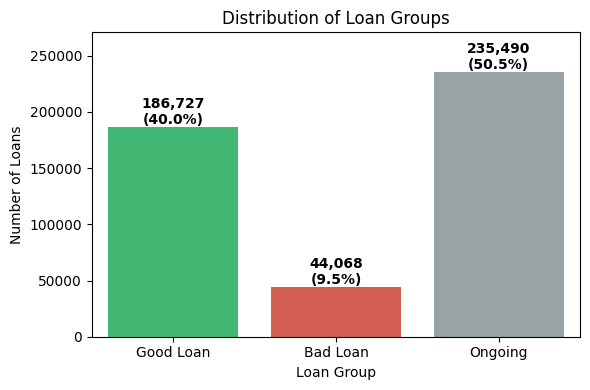

In [12]:
# Plot distribution of loan groups
plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=df_target,
    x='Loan Group',
    y='Count',
    hue='Loan Group',
    palette={'Good Loan': '#2ecc71', 'Bad Loan': '#e74c3c', 'Ongoing': '#95a5a6'},
    legend=False,
    order=['Good Loan', 'Bad Loan', 'Ongoing']
)

plt.title('Distribution of Loan Groups')
plt.xlabel('Loan Group')
plt.ylabel('Number of Loans')

# Add count and percentage labels
for i, row in df_target.iterrows():
    ax.text(
        ['Good Loan', 'Bad Loan', 'Ongoing'].index(row['Loan Group']),
        row['Count'],
        f"{row['Count']:,}\n({row['Percentage']:.1f}%)",
        ha='center',
        va='bottom',
        fontweight='bold'
    )
plt.ylim(0, df_target['Count'].max() * 1.15)
plt.tight_layout()
plt.show()

# 3. Missing Value Analysis

The missing value analysis is conducted to assess data quality and identify potential information
contained within missing data.

The approach includes:
- **Measuring** the count and percentage of missing values for each feature
- **Grouping** features based on their level of missingness
- **Evaluating** the relationship between missing values and the *default rate*

The results of this analysis serve as recommendations for the data handling stage, including:
- **Imputing values** for features with moderate missingness
- **Creating missing indicators** to capture potential risk patterns associated with missing data
- **Considering removal** of features with very high missing rates or zero predictive signal

## 3.1 Missing Values Count
This section calculates the count and percentage of missing values for each feature,
along with its data type.

In [13]:
# Check missing values: count, percentage, and data type per feature
df_missing = (
    df.isnull()
    .agg(['sum', 'mean'])
    .T
    .rename(columns={
        'sum': 'Missing_Count',
        'mean': 'Missing_Percentage'
    })
    .assign(
        Missing_Percentage=lambda x: (x['Missing_Percentage'] * 100).round(2),
        Data_Type=df.dtypes
    )
    .query('Missing_Count > 0')
    .sort_values('Missing_Percentage', ascending=False)
    .reset_index(names='Feature')
)

print(df_missing)

                        Feature  Missing_Count  Missing_Percentage Data_Type
0                        inq_fi       466285.0              100.00   float64
1                   open_rv_24m       466285.0              100.00   float64
2                    max_bal_bc       466285.0              100.00   float64
3                      all_util       466285.0              100.00   float64
4                  inq_last_12m       466285.0              100.00   float64
5              annual_inc_joint       466285.0              100.00   float64
6     verification_status_joint       466285.0              100.00   float64
7                     dti_joint       466285.0              100.00   float64
8                   total_cu_tl       466285.0              100.00   float64
9                       il_util       466285.0              100.00   float64
10           mths_since_rcnt_il       466285.0              100.00   float64
11                 total_bal_il       466285.0              100.00   float64

## 3.2 Default Rate to Missing Features

This section examines whether missing values carry predictive signal by comparing
the default rate between rows where data is present versus missing.

> **Note:** Default rate is calculated on resolved loans only (Good Loan and Bad Loan),
> excluding Ongoing loans where the final outcome is unknown.

In [14]:
# Create binary target from loan_group (resolved loans only)
df_resolved = df[df['loan_group'].isin(['Good Loan', 'Bad Loan'])].copy()
df_resolved['is_default'] = (df_resolved['loan_group'] == 'Bad Loan').astype(int)

# Features with missing values (excluding 100% null columns)
all_missing_features = df_missing[
    (df_missing['Missing_Count'] > 0) &
    (df_missing['Missing_Percentage'] < 100)
]['Feature'].tolist()

# Summary of missing percentage and default rate comparison
missing_default_rate = pd.DataFrame([
    {
        'Feature': col,
        'Missing_Percentage (%)': df_missing.set_index('Feature').loc[col, 'Missing_Percentage'],
        'Default Rate (Not Missing) (%)':
            df_resolved.loc[df_resolved[col].notna(), 'is_default'].mean() * 100,
        'Default Rate (Missing) (%)':
            df_resolved.loc[df_resolved[col].isna(), 'is_default'].mean() * 100,
    }
    for col in all_missing_features
    if col in df_resolved.columns
])

missing_default_rate = (
    missing_default_rate
    .set_index('Feature')
    .round(2)
)

missing_default_rate

,Missing_Percentage (%),Default Rate (Not Missing) (%),Default Rate (Missing) (%)
Feature,,,
mths_since_last_record,86.57,20.10,18.96
mths_since_last_major_derog,78.77,20.30,18.84
desc,72.98,17.57,20.08
mths_since_last_delinq,53.69,19.48,18.80
next_pymnt_d,48.73,44.48,18.69
tot_cur_bal,15.07,20.25,16.24
tot_coll_amt,15.07,20.25,16.24
total_rev_hi_lim,15.07,20.25,16.24
emp_title,5.92,18.69,25.87


### Key Findings & Handling Strategy

Most missing features show **higher default rate when missing**, meaning missingness itself
is a risk signal worth preserving. A few features show the opposite pattern where missing rows
have **lower default rate**, but remain informative nonetheless.

**Missing Indicator** is a new binary column (0/1) to flag whether a value was originally missing,
before the NaN is filled with an imputed value. For features with **more than 50% missing**,
consider dropping the original feature and keeping only the `_MISSING` indicator to avoid noise.

**All-Null Columns (100% missing)**
`inq_fi`, `open_rv_24m`, `max_bal_bc`, `all_util`, `inq_last_12m`, `annual_inc_joint`,
`dti_joint`, `verification_status_joint`, `total_cu_tl`, `il_util`, `mths_since_rcnt_il`,
`total_bal_il`, `open_il_24m`, `open_il_12m`, `open_il_6m`, `open_acc_6m`, `open_rv_12m` —
Drop entirely, no predictive value.

**Numerical Features**
- **> 50% missing**: `mths_since_last_record` (86.57%), `mths_since_last_major_derog` (78.77%),
  `mths_since_last_delinq` (53.69%) — Drop original, missingness difference is minimal.
- **10–50% missing**: `tot_cur_bal`, `tot_coll_amt`, `total_rev_hi_lim` (15.07% each) — Median Impute.
- **< 1% missing**: `revol_util`, `collections_12_mths_ex_med`, `delinq_2yrs`, `inq_last_6mths`,
  `open_acc`, `acc_now_delinq`, `pub_rec`, `total_acc`, `annual_inc` — Simple Median Impute, no indicator needed.

**Categorical Features**
- **> 50% missing**: `desc` (72.98%) — Drop, free-text field with no direct predictive value.
- **~50% missing**: `next_pymnt_d` (48.73%) — Drop, post-origination leakage feature.
- **< 10% missing**: `emp_title` (5.92%), `emp_length` (4.51%) — Missing Indicator + Mode Impute,
  missingness shows notably higher default rate (25–27%).
- **< 1% missing**: `last_pymnt_d`, `last_credit_pull_d`, `earliest_cr_line`, `title` — Simple Mode Impute, no indicator needed.

> ⚠️ `last_pymnt_d` shows **100% default rate when missing**, and `next_pymnt_d` shows extreme
> default rate difference (44.48% vs 18.69%). Both are post-origination features and must be
> evaluated carefully for **data leakage** before modeling.

---

# 4. Numerical Features Analysis


## 4.1 Univariate Analysis

Univariate analysis examines each numerical feature independently to understand
its distribution, central tendency, and spread. This serves as the foundation
before exploring relationships between features and the target variable.

The approach includes:
- **Describing** each feature through summary statistics (mean, median, std, min, max)
- **Identifying** potential anomalies, skewness, and extreme values

### 4.1.1 Statistical Descriptive

In [15]:
# Select numerical features and display descriptive statistics
df.select_dtypes(include='number').describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,466285.0,2.331420e+05,1.346050e+05,0.00,1.165710e+05,2.331420e+05,3.497130e+05,4.662840e+05
id,466285.0,1.307973e+07,1.089371e+07,54734.00,3.639987e+06,1.010790e+07,2.073121e+07,3.809811e+07
member_id,466285.0,1.459766e+07,1.168237e+07,70473.00,4.379705e+06,1.194108e+07,2.300154e+07,4.086083e+07
loan_amnt,466285.0,1.431728e+04,8.286509e+03,500.00,8.000000e+03,1.200000e+04,2.000000e+04,3.500000e+04
funded_amnt,466285.0,1.429180e+04,8.274371e+03,500.00,8.000000e+03,1.200000e+04,2.000000e+04,3.500000e+04
funded_amnt_inv,466285.0,1.422233e+04,8.297638e+03,0.00,8.000000e+03,1.200000e+04,1.995000e+04,3.500000e+04
int_rate,466285.0,1.382924e+01,4.357587e+00,5.42,1.099000e+01,1.366000e+01,1.649000e+01,2.606000e+01
installment,466285.0,4.320612e+02,2.434855e+02,15.67,2.566900e+02,3.798900e+02,5.665800e+02,1.409990e+03
annual_inc,466281.0,7.327738e+04,5.496357e+04,1896.00,4.500000e+04,6.300000e+04,8.896000e+04,7.500000e+06
dti,466285.0,1.721876e+01,7.851121e+00,0.00,1.136000e+01,1.687000e+01,2.278000e+01,3.999000e+01


In [16]:
# Check value distribution of key categorical-like numerical features
print("policy_code:\n", df['policy_code'].value_counts())
print("\nacc_now_delinq:\n", df['acc_now_delinq'].value_counts().head())
print("\ndelinq_2yrs:\n", df['delinq_2yrs'].value_counts().head())
print("\npub_rec:\n", df['pub_rec'].value_counts().head())
print("\ncollections_12_mths_ex_med:\n", df['collections_12_mths_ex_med'].value_counts().head())

policy_code:
 policy_code
1    466285
Name: count, dtype: int64

acc_now_delinq:
 acc_now_delinq
0.0    464524
1.0      1623
2.0        92
3.0        11
4.0         4
Name: count, dtype: int64

delinq_2yrs:
 delinq_2yrs
0.0    382954
1.0     56224
2.0     16310
3.0      5684
4.0      2378
Name: count, dtype: int64

pub_rec:
 pub_rec
0.0    404893
1.0     53051
2.0      5624
3.0      1611
4.0       520
Name: count, dtype: int64

collections_12_mths_ex_med:
 collections_12_mths_ex_med
0.0    462226
1.0      3665
2.0       219
3.0        19
4.0         7
Name: count, dtype: int64


#### Key Findings

**Near-Zero Variance — Consider Dropping**
`policy_code` is constant across all 466,285 records (value = 1), carrying no predictive value.
Drop entirely before modeling.

**Anomalies Detected**
`revol_util` max = 892.3%, which is abnormal since utilization rate should not exceed 100%.
`annual_inc` max = 7,500,000 and `tot_coll_amt` max = 9,152,545, both are extreme outliers
that require capping before modeling.
`tot_cur_bal` max = 8,000,078 and `total_rev_hi_lim` max = 9,999,999, extreme upper values
suggest data entry errors or extreme cases that need investigation.

**Skewed Distributions**
`loan_amnt`, `funded_amnt`, `annual_inc`, `revol_bal`, and `tot_coll_amt` are right-skewed,
with large gaps between median and max values. Log transformation may be required.
`recoveries` and `collection_recovery_fee` have median = 0 with high max values,
indicating most loans have no recovery activity.

**Credit Behavior Features**
`delinq_2yrs`, `pub_rec`, `acc_now_delinq`, and `collections_12_mths_ex_med` are heavily
concentrated at 0, meaning most borrowers have clean credit history.
Sparse non-zero values may need grouping (e.g. 0, 1, 2+) before modeling.

**Post-Origination Features — Potential Leakage**
`total_pymnt`, `total_rec_prncp`, `total_rec_int`, `recoveries`, `out_prncp`, and
`last_pymnt_amnt` reflect repayment activity after loan issuance. These features are
not available at the time of application and must be excluded from modeling.

**Features for Further Analysis**
- `loan_amnt`, `int_rate`, `annual_inc`, `dti` to check distribution shape and skewness
- `revol_util`, `revol_bal` to confirm outlier severity
- `delinq_2yrs`, `pub_rec` to check distribution of credit behavior features
- `tot_coll_amt`, `tot_cur_bal` to check extreme value patterns

### 4.1.2 Distribution Plot

Distribution plots are used to examine the shape of each numerical feature —
whether it is normally distributed, right-skewed, or contains anomalies.
Features with high skewness may require log transformation during preprocessing.

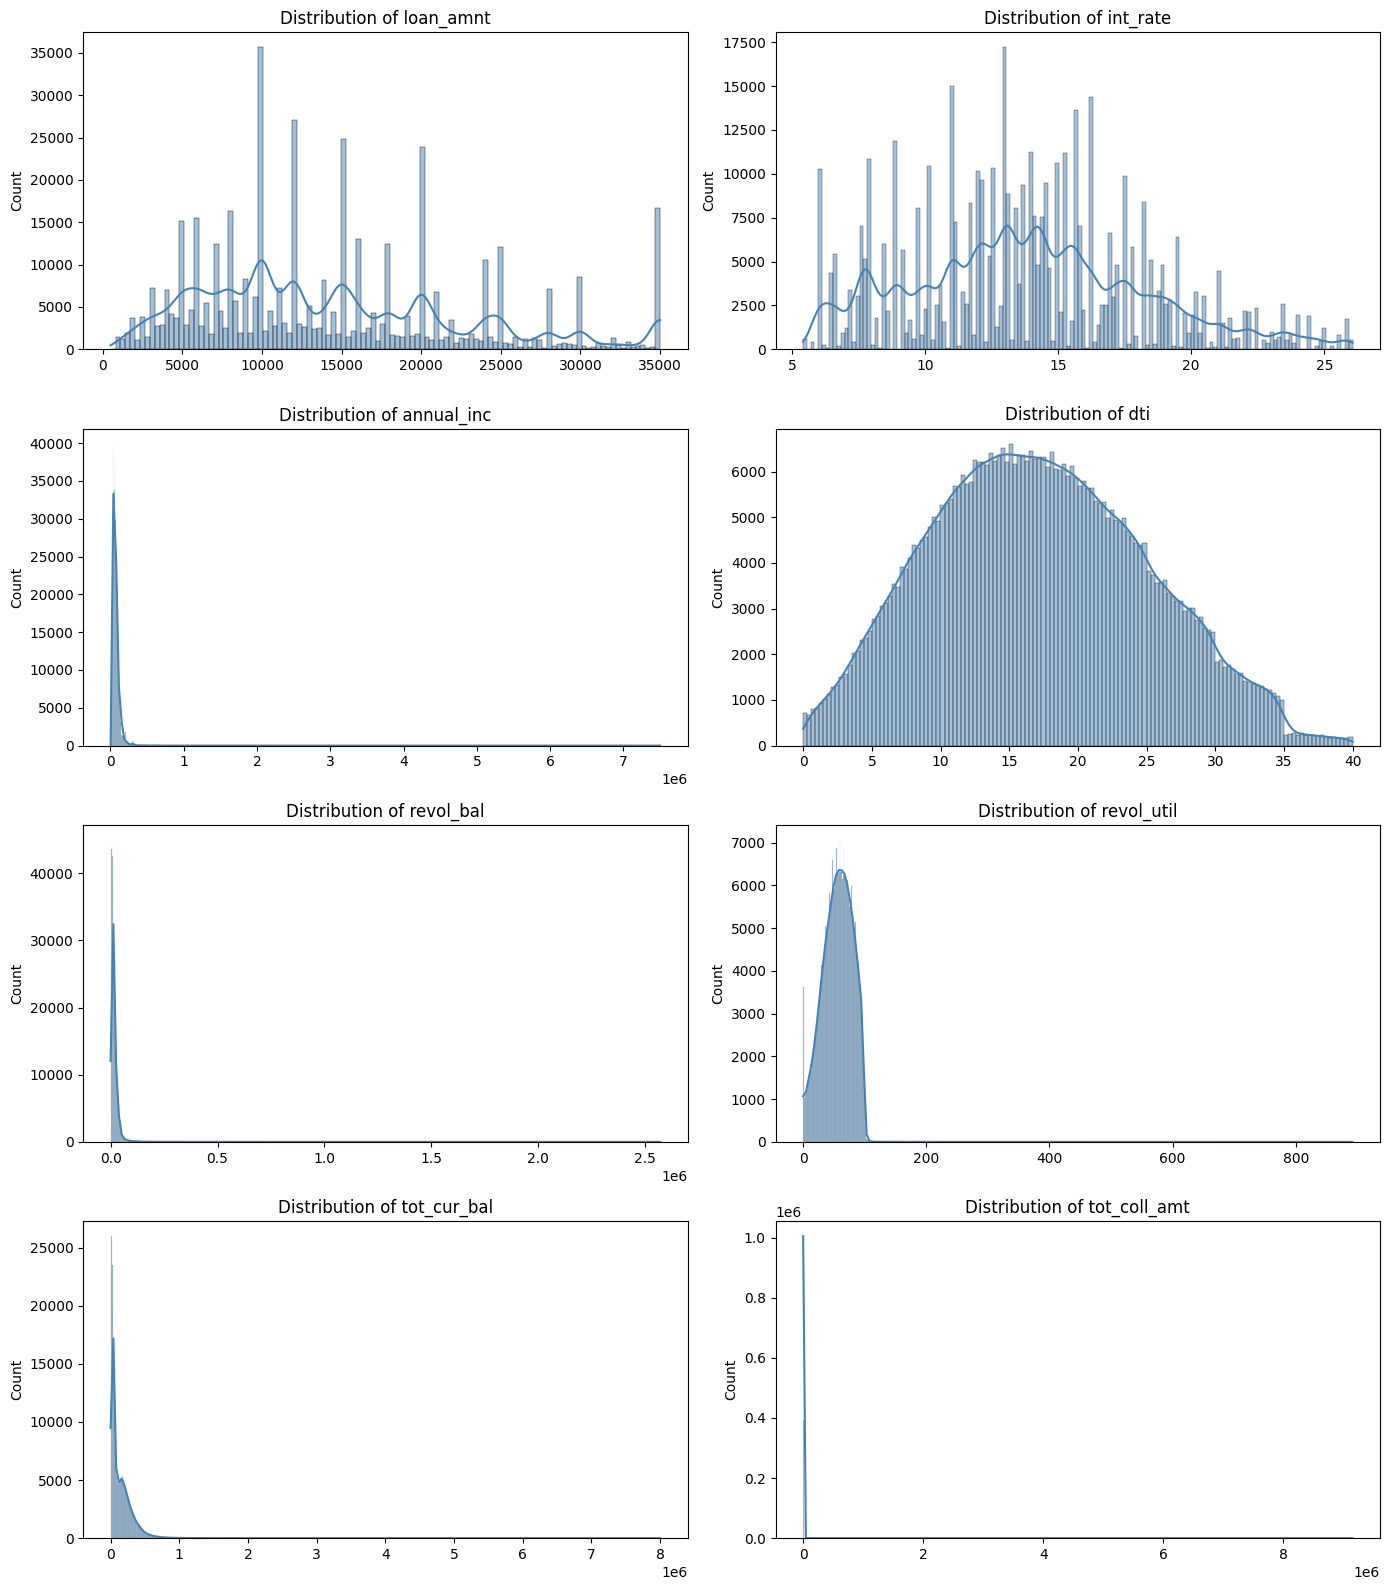

In [17]:
# Select key numerical features for distribution analysis
num_features = [
    'loan_amnt', 'int_rate', 'annual_inc', 'dti',
    'revol_bal', 'revol_util', 'tot_cur_bal', 'tot_coll_amt'
]

# Grid 4x2
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(num_features):
    # Histogram + KDE
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

#### Key Findings

**loan_amnt**
Distribution shows multiple peaks at round numbers (5k, 10k, 15k, 20k), indicating borrowers
tend to request loans in round amounts. Relatively well-spread across the range with no extreme skew.

**int_rate**
Multimodal distribution with spikes across the range, reflecting LC's grade-based interest rate
assignment. Most loans cluster between 10% and 16%, consistent with grades B and C.

**annual_inc**
Extremely right-skewed with the vast majority of borrowers concentrated below 200k,
while a small number of extreme values extend up to 7.5 million.
Requires capping or log transformation before modeling.

**dti**
Relatively bell-shaped and well-distributed between 0 and 40, with a peak around 15.
Most well-behaved feature among all analyzed, minimal transformation needed.

**revol_bal**
Heavily right-skewed with most values concentrated near zero and a long tail extending
to 2.5 million. Extreme outliers confirmed, requires capping or log transformation.

**revol_util**
Extreme outlier visible at ~800%, far beyond the normal 0–100% range.
The main distribution is concentrated between 0 and 100%, confirming the anomaly
identified in the statistical descriptive section. Requires capping at 100%.

**tot_cur_bal**
Right-skewed with most values below 500k and a long tail extending to 8 million.
Consistent with `annual_inc` pattern, requires capping or log transformation.

**tot_coll_amt**
Extremely concentrated at zero with almost no visible distribution beyond 0.
Confirms that the vast majority of borrowers have no collection history.
Extreme outliers at upper end require capping.

### 4.1.3 Outlier Detection

Boxplots are used to detect outliers in key numerical features.
Extreme values can distort model training and may require capping or
domain-aware treatment before modeling.

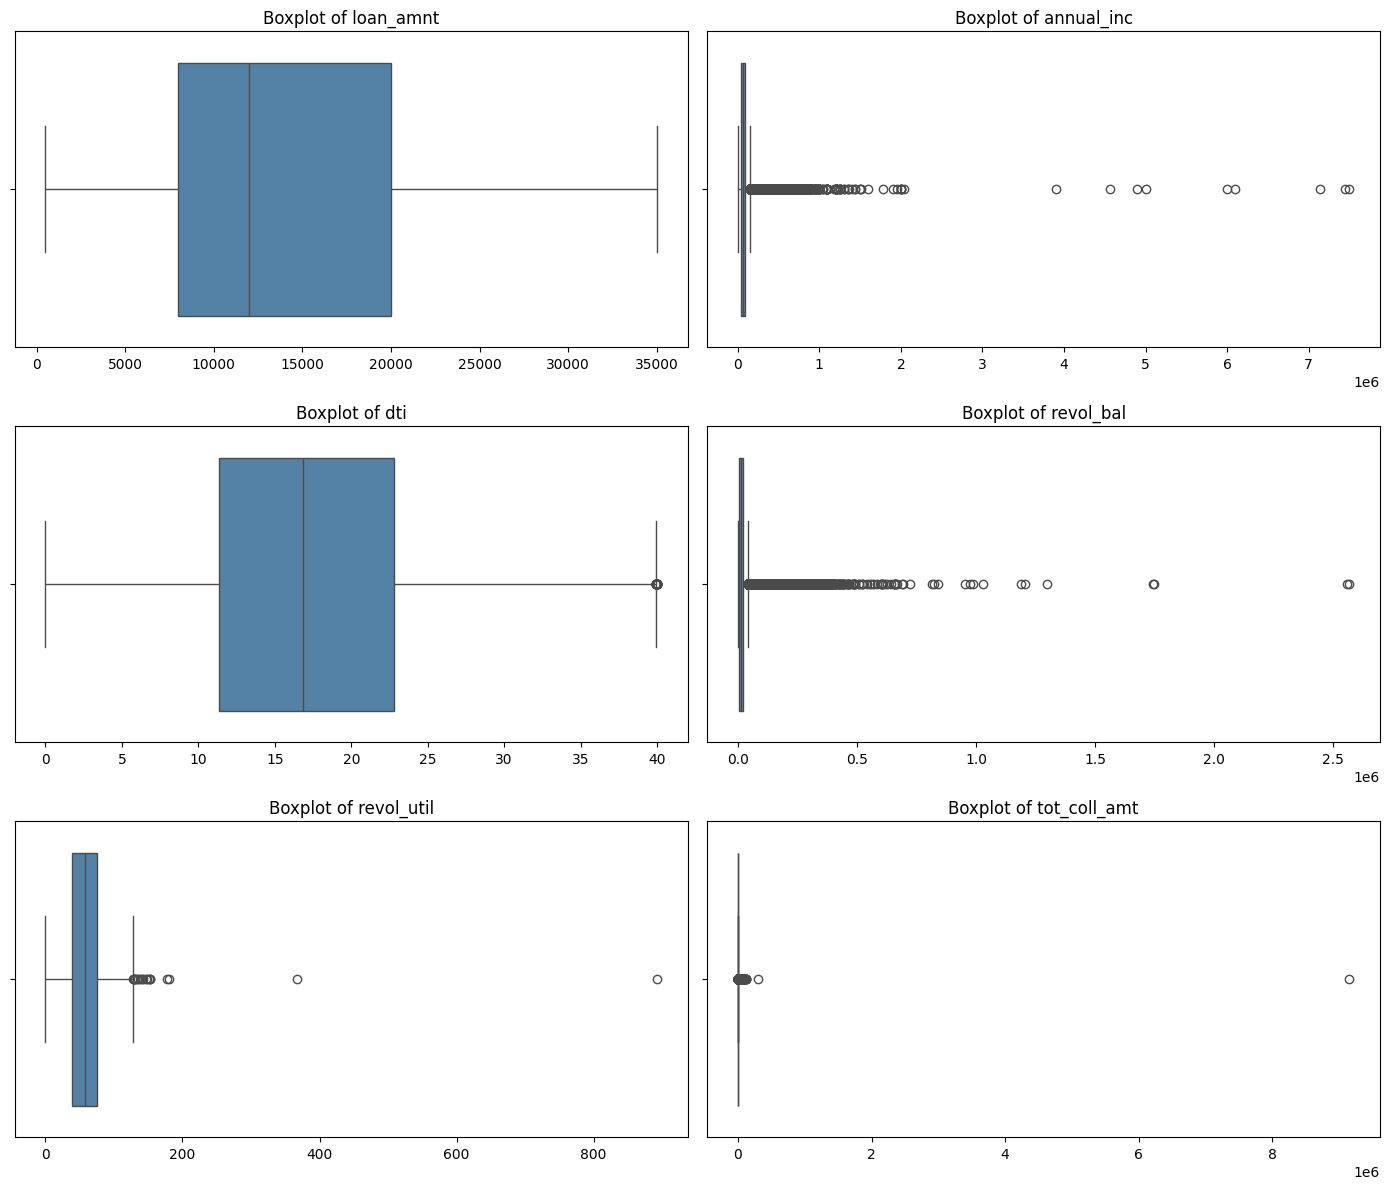

In [18]:
# Select key numerical features for outlier detection
outlier_features = [
    'loan_amnt', 'annual_inc', 'dti',
    'revol_bal', 'revol_util', 'tot_coll_amt'
]

# Grid 3x2
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(outlier_features):
    # Boxplot
    sns.boxplot(x=df[col].dropna(), ax=axes[i], color='steelblue')
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

#### Key Findings

- `loan_amnt` well-distributed within range with moderate spread, no extreme outliers detected.
- `annual_inc` extreme outliers visible up to 7.5 million, majority compressed near zero. **Needs capping.**
- `dti` one visible outlier at ~40 but otherwise well-behaved, minimal treatment needed.
- `revol_bal` extreme outliers extending to 2.5 million, main distribution heavily compressed near zero. **Needs capping.**
- `revol_util` extreme outlier at ~892%, far beyond the valid 0–100% range. **Needs capping at 100%.**
- `tot_coll_amt` single extreme outlier at ~9 million with virtually all values at zero. **Needs capping.**

All features above except `loan_amnt` and `dti` require outlier treatment before modeling.
Capping at a defined percentile (e.g. 99th) is recommended for financial features,
and hard capping at 100% for `revol_util`.

---

## 4.2 Bivariate Analysis

This section examines the relationship between numerical features and the target variable (`loan_group`).
The goal is to identify which numerical features show the strongest separation between
Good Loan and Bad Loan borrowers.

The approach includes:
- **Comparing** distributions of each numerical feature between Good Loan and Bad Loan groups
- **Evaluating** default rate across binned value ranges to identify high-risk segments

### 4.2.1 Distribution By Target (KDE Plot)

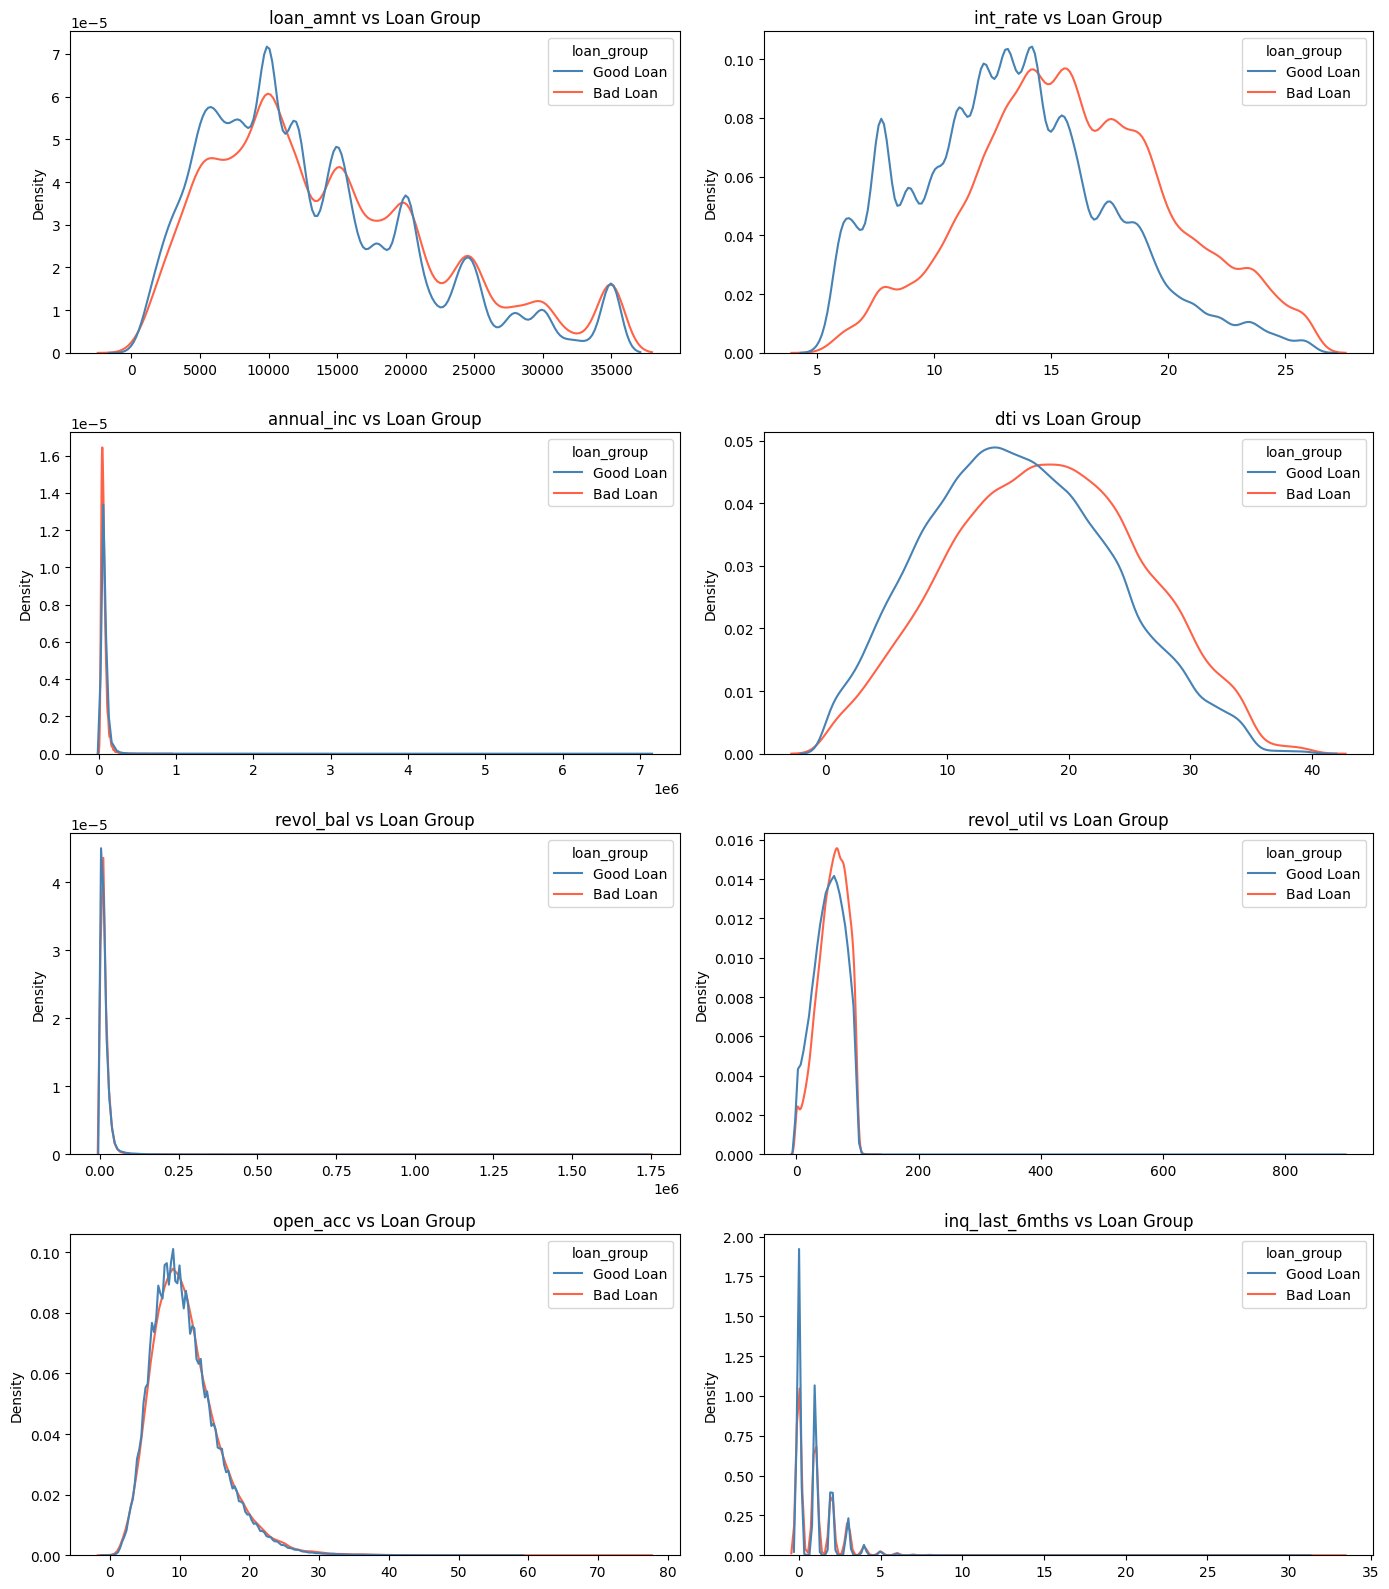

In [19]:
# Select key numerical features for bivariate analysis vs loan_group
num_features = [
    'loan_amnt', 'int_rate', 'annual_inc', 'dti',
    'revol_bal', 'revol_util', 'open_acc', 'inq_last_6mths'
]

# Filter resolved loans only
df_resolved = df[df['loan_group'].isin(['Good Loan', 'Bad Loan'])].copy()

# Grid 4x2
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(num_features):
    # KDE plot per group, common_norm=False to handle class imbalance
    sns.kdeplot(
        data=df_resolved, x=col,
        hue='loan_group', common_norm=False,
        ax=axes[i],
        palette={'Good Loan': 'steelblue', 'Bad Loan': 'tomato'}
    )
    axes[i].set_title(f'{col} vs Loan Group')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

#### Key Findings

**loan_amnt**
Both groups show very similar distribution shapes with overlapping peaks at round amounts.
Loan amount alone shows weak discriminative power between Good and Bad Loan borrowers.

**int_rate**
Clearest separation among all features. Bad Loan concentrates at higher interest rates (13–20%),
while Good Loan peaks at lower rates (10–13%). **Higher interest rate is strongly associated
with higher default risk**, consistent with LC's grade-based risk pricing.

**annual_inc**
Both groups are heavily compressed near zero due to extreme outliers, making separation
barely distinguishable. Confirms that income alone is not a strong predictor of default risk.

**dti**
Bad Loan distribution shifts slightly toward higher DTI values compared to Good Loan.
Borrowers with higher debt-to-income ratio carry moderately higher default risk,
though the separation is not sharp.

**revol_bal**
Both groups are nearly identical and heavily concentrated near zero.
Revolving balance shows **very low discriminative power** against loan outcome.

**revol_util**
Distributions are largely overlapping with Bad Loan showing a slight shift toward
higher utilization. Weak but present signal, extreme outliers distort the plot significantly.

**open_acc**
Distributions are almost perfectly overlapping across both groups.
Number of open accounts shows **no meaningful separation** between Good and Bad Loan.

**inq_last_6mths**
Both groups heavily concentrated at 0–2 inquiries with near-identical distributions.
Credit inquiries in the last 6 months show minimal discriminative power.

---

### 4.2.2 Default Rate by Binned Feature

Numerical features are divided into bins to calculate the default rate per group.
This makes it easier to identify at which value range the default risk is highest.

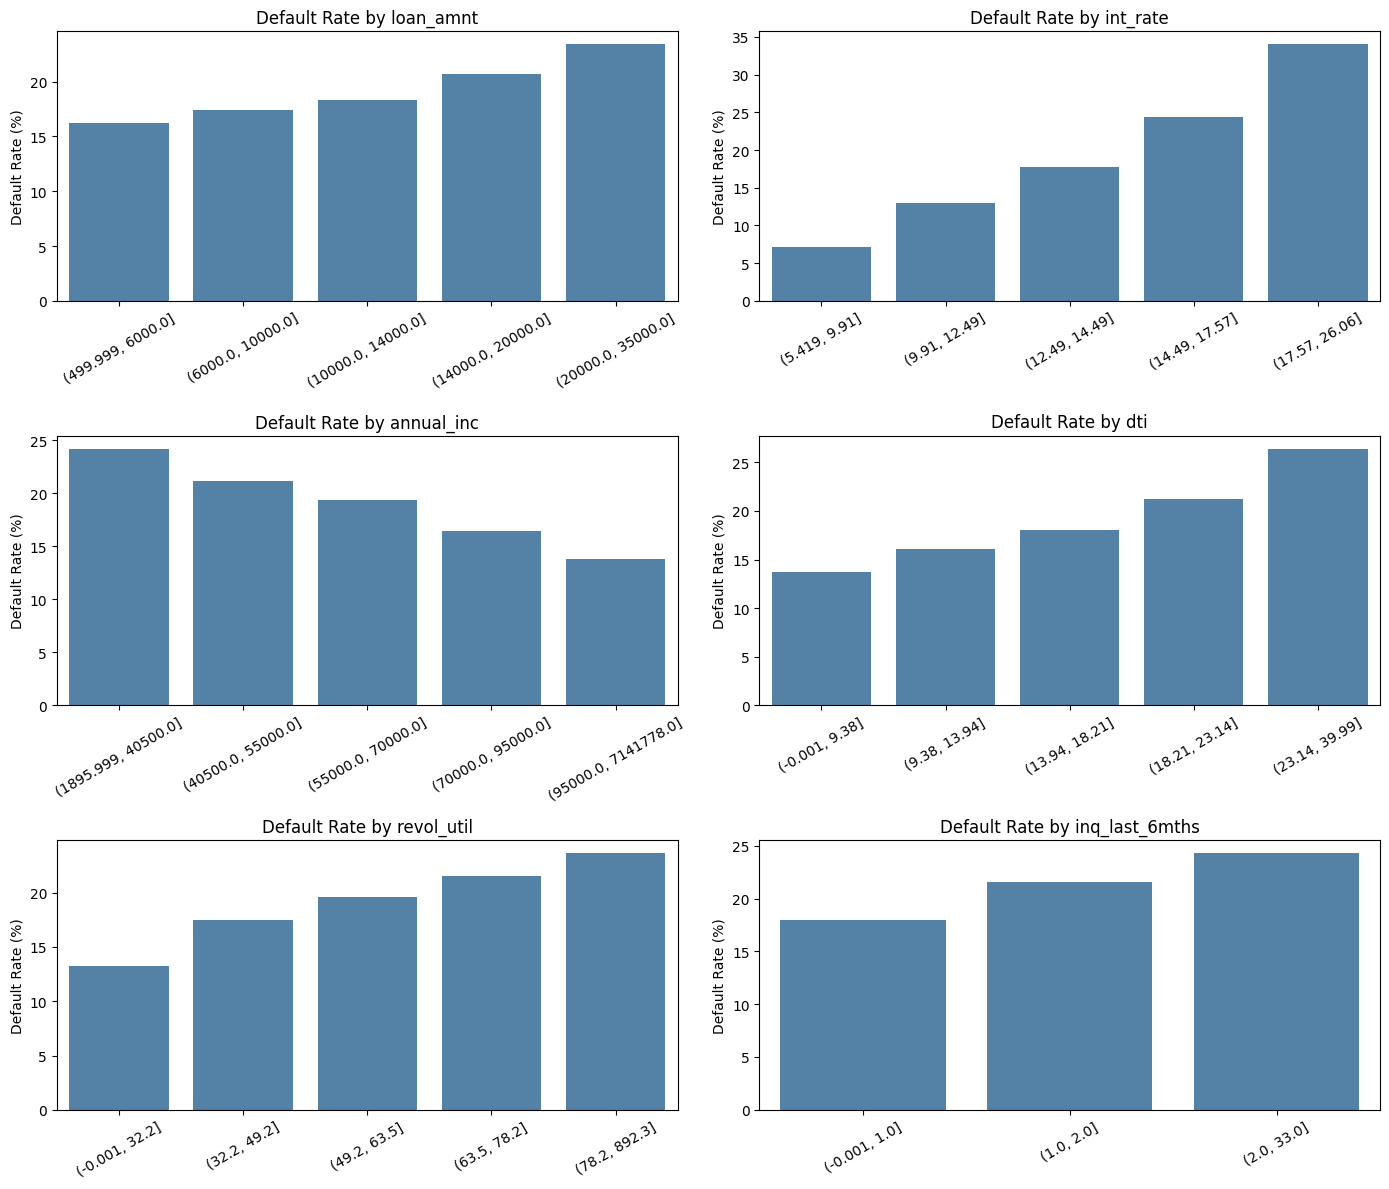

In [20]:
# Select key features for binned default rate analysis
bin_features = {
    'loan_amnt': 5,
    'int_rate': 5,
    'annual_inc': 5,
    'dti': 5,
    'revol_util': 5,
    'inq_last_6mths': 5
}

# Filter resolved loans only
df_resolved = df[df['loan_group'].isin(['Good Loan', 'Bad Loan'])].copy()
df_resolved['is_default'] = (df_resolved['loan_group'] == 'Bad Loan').astype(int)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for i, (col, bins) in enumerate(bin_features.items()):
    temp = df_resolved[[col, 'is_default']].dropna().copy()
    temp[f'{col}_BIN'] = pd.qcut(temp[col], q=bins, duplicates='drop')
    default_rate = temp.groupby(f'{col}_BIN', observed=True)['is_default'].mean() * 100

    sns.barplot(
        x=default_rate.index.astype(str),
        y=default_rate.values,
        ax=axes[i],
        color='steelblue'
    )
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Default Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

#### Key Findings

**loan_amnt**
Clear increasing trend where larger loan amounts are associated with higher default risk.
Default rate rises from ~16% at the lowest bin to ~23% at the highest bin (above 20k).
Loan amount is a meaningful predictor of default risk.

**int_rate**
Strongest and most consistent pattern among all features. Default rate increases sharply
from ~7% at the lowest rates (below 9.91%) up to ~34% at the highest rates (above 17.57%).
**Interest rate is the most discriminative numerical predictor of default risk.**

**annual_inc**
Clear inverse relationship where higher income is associated with lower default risk.
Default rate drops from ~24% at the lowest income bin down to ~14% at the highest bin.
Confirms that income carries meaningful predictive signal despite compressed distribution.

**dti**
Consistent increasing trend where higher debt-to-income ratio leads to higher default risk.
Default rate rises from ~14% at the lowest DTI bin up to ~26% at the highest bin (above 23.14).
DTI is a strong and actionable risk indicator.

**revol_util**
Steady increasing trend from ~13% at low utilization (below 32.2%) up to ~23% at the
highest bin (above 78.2%). Higher revolving credit utilization is associated with higher default risk,
confirming its predictive value despite the extreme outlier at ~892%.

**inq_last_6mths**
Moderate increasing trend where more recent credit inquiries are associated with higher default risk.
Default rate rises from ~18% at 0 inquiries up to ~24% at 2 or more inquiries.
Suggests that frequent credit-seeking behavior is a mild but consistent risk signal.

---

# 5. Categorical Features Analysis

## 5.1 Univariate Analysis

Univariate analysis for categorical features examines each feature independently
to understand its category distribution, frequency, and concentration.

The approach includes:
- **Describing** each feature through unique value counts, most frequent category, and its frequency percentage
- **Identifying** dominant categories, near-constant features, and rare categories that may need handling

### 5.1.1 Statistical Descriptive

In [22]:
# Select all categorical features
cat_features = df.select_dtypes(include='object').columns

# Build summary: unique values, most frequent category, and its frequency
cat_summary = pd.DataFrame({
    'Unique_Values': df[cat_features].nunique(),
    'Most_Frequent': df[cat_features].apply(lambda x: x.value_counts().index[0]),
    'Frequency': df[cat_features].apply(lambda x: x.value_counts().iloc[0]),
    # Frequency as percentage of non-missing rows
    'Frequency_%': df[cat_features].apply(
        lambda x: (x.value_counts().iloc[0] / x.count() * 100).round(2)
    )
})

cat_summary

,Unique_Values,Most_Frequent,Frequency,Frequency_%
term,2,36 months,337953,72.48
grade,7,B,136929,29.37
sub_grade,35,B3,31686,6.80
emp_title,205475,Teacher,5399,1.23
emp_length,11,10+ years,150049,33.70
home_ownership,6,MORTGAGE,235875,50.59
verification_status,3,Verified,168055,36.04
issue_d,91,Oct-14,38782,8.32
loan_status,9,Current,224226,48.09
pymnt_plan,2,n,466276,100.00


In [23]:
# Check value counts for key categorical features
for col in ['term', 'grade', 'home_ownership', 'verification_status',
            'purpose', 'emp_length', 'initial_list_status']:
    print(f"\n{col}:")
    print(df[col].value_counts())


term:
term
36 months    337953
60 months    128332
Name: count, dtype: int64

grade:
grade
B    136929
C    125293
D     76888
A     74867
E     35757
F     13229
G      3322
Name: count, dtype: int64

home_ownership:
home_ownership
MORTGAGE    235875
RENT        188473
OWN          41704
OTHER          182
NONE            50
ANY              1
Name: count, dtype: int64

verification_status:
verification_status
Verified           168055
Source Verified    149993
Not Verified       148237
Name: count, dtype: int64

purpose:
purpose
debt_consolidation    274195
credit_card           104157
home_improvement       26537
other                  23690
major_purchase          9828
small_business          7013
car                     5397
medical                 4602
moving                  2994
vacation                2487
wedding                 2343
house                   2269
educational              422
renewable_energy         351
Name: count, dtype: int64

emp_length:
emp_length
10+ ye

#### Key Findings

**Near-Constant Features — Consider Dropping**
`pymnt_plan` is 100% `n` and `application_type` is 100% `INDIVIDUAL`, both are constant
across all records and carry zero predictive value. Drop entirely before modeling.

**High Cardinality — Consider Dropping or Grouping**
`emp_title` has 205,475 unique values, `url` has 466,285 unique values (one per row),
`title` has 63,098 unique values, and `zip_code` has 888 unique values.
These features are too granular for direct use and should be dropped or heavily engineered.
`addr_state` has 50 unique values, consider grouping by region if used.

**Dominant Categories**
`purpose` is 58.8% `debt_consolidation`, heavily dominated by one category.
`term` is 72.5% `36 months`, most borrowers prefer shorter loan terms.
`emp_length` is 33.7% `10+ years`, suggesting a large portion of experienced borrowers.
`home_ownership` is 50.6% `MORTGAGE`, followed by `RENT` at 40.4%.

**Rare Categories — Needs Handling**
`home_ownership` contains `OTHER` (182), `NONE` (50), and `ANY` (1), consider grouping
these into a single `OTHER` category before modeling.
`purpose` contains `renewable_energy` (351) and `educational` (422) with very few records,
consider grouping rare purposes into `other`.

**Date Features — Not for Direct Modeling**
`issue_d`, `earliest_cr_line`, `last_pymnt_d`, `next_pymnt_d`, and `last_credit_pull_d`
are date strings that require parsing and feature engineering before use in modeling.

**Features for Further Analysis**
- `grade`, `verification_status`, `purpose`, `home_ownership`, `emp_length` have
  sufficient variation to explore default rate differences across categories.
- `term` and `initial_list_status` to confirm default rate difference between groups.

### 5.1.2 Frequency Plot
Bar plots are used to visualize the frequency distribution of each categorical feature.
This helps identify dominant categories, class imbalance within features,
and rare categories that may need grouping before modeling.

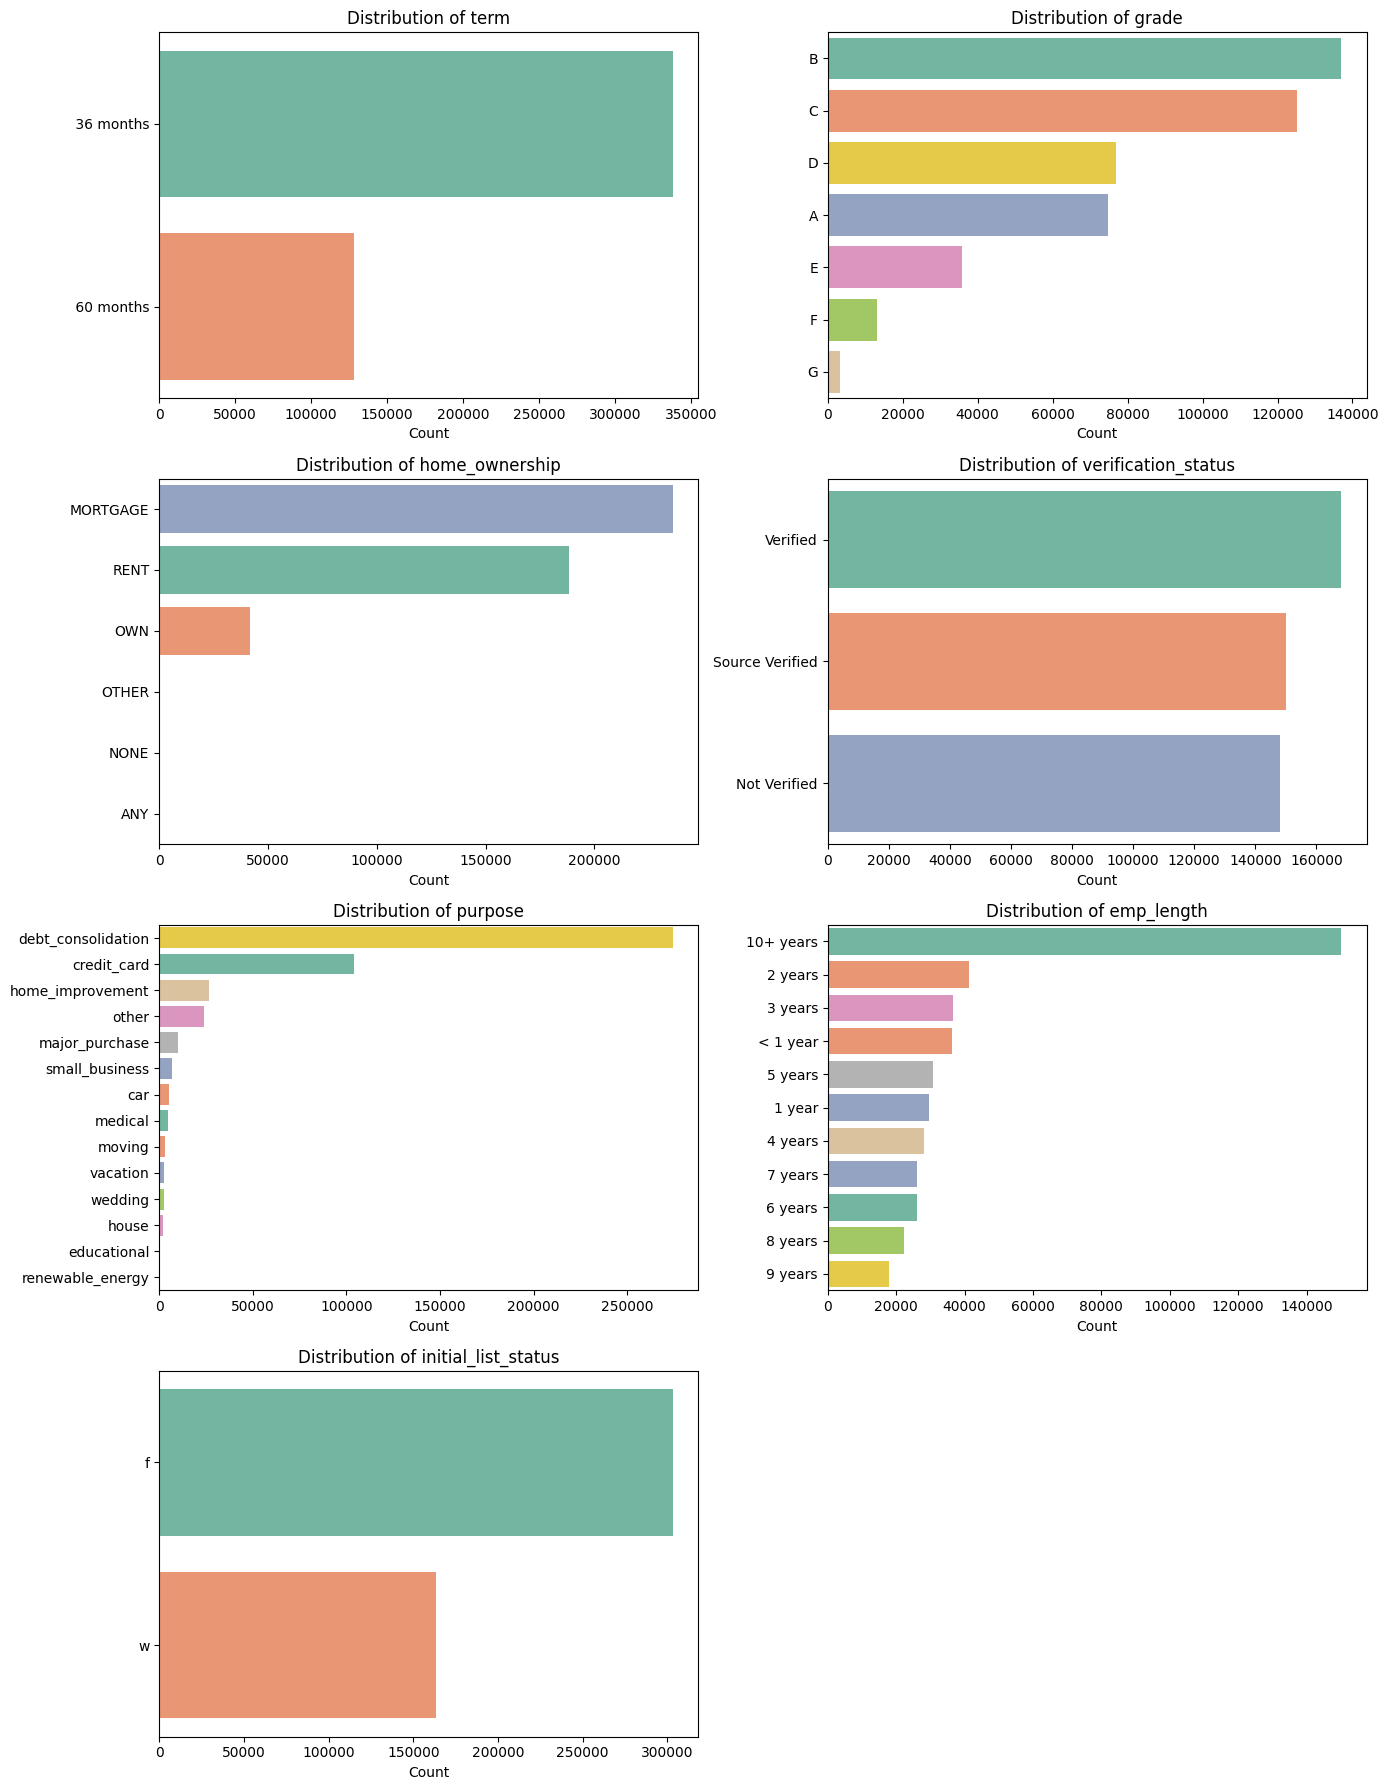

In [26]:
# Select key categorical features for frequency plot
cat_plot_features = [
    'term', 'grade', 'home_ownership', 'verification_status',
    'purpose', 'emp_length', 'initial_list_status'
]

# Grid 4x2
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(cat_plot_features):
    # Sort bars by frequency
    order = df[col].value_counts().index
    # Horizontal bar plot
    sns.countplot(
        data=df, y=col,
        order=order, ax=axes[i],
        hue=col, palette='Set2', legend=False
    )
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('')

# Hide unused subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

#### Key Findings

**term**
Loan term is heavily skewed toward 36 months (~338k) compared to 60 months (~128k).
Most borrowers prefer shorter loan terms, which may reflect lower risk appetite.

**grade**
Grades B and C dominate the dataset (~136k and ~125k respectively), representing
mid-range risk borrowers. Grade A (lowest risk) has fewer records than B and C,
while grades F and G (highest risk) are rare with combined records below 17k.

**home_ownership**
MORTGAGE and RENT together account for over 90% of all borrowers.
OWN is a distant third at ~42k, while OTHER, NONE, and ANY are negligible
and should be grouped before modeling.

**verification_status**
Fairly balanced across three categories with Verified (~168k), Source Verified (~150k),
and Not Verified (~148k). No dominant category, all three carry analytical value.

**purpose**
Heavily dominated by `debt_consolidation` (~274k, 58.8%) followed by `credit_card` (~104k).
Remaining 12 categories are significantly smaller, with `renewable_energy` and `educational`
having very few records. Consider grouping rare purposes into `other`.

**emp_length**
`10+ years` dominates at ~150k (33.7%), suggesting a large proportion of experienced borrowers.
Remaining categories are more evenly distributed between 1 and 9 years.
`< 1 year` (~36k) is notable and should be retained as a separate category.

**initial_list_status**
`f` (fractional) dominates at ~303k (65%) versus `w` (whole) at ~163k (35%).
Both categories are sufficiently represented for analysis.

## 5.2 Bivariate Analysis

This section examines the relationship between categorical features and the target variable (`loan_group`).
The goal is to identify which categories carry the highest default risk.

The approach includes:
- **Evaluating** default rate differences across categories of each feature
- **Identifying** high-risk and low-risk groups within each categorical feature

### 5.2.1 Categorical Features Vs Target

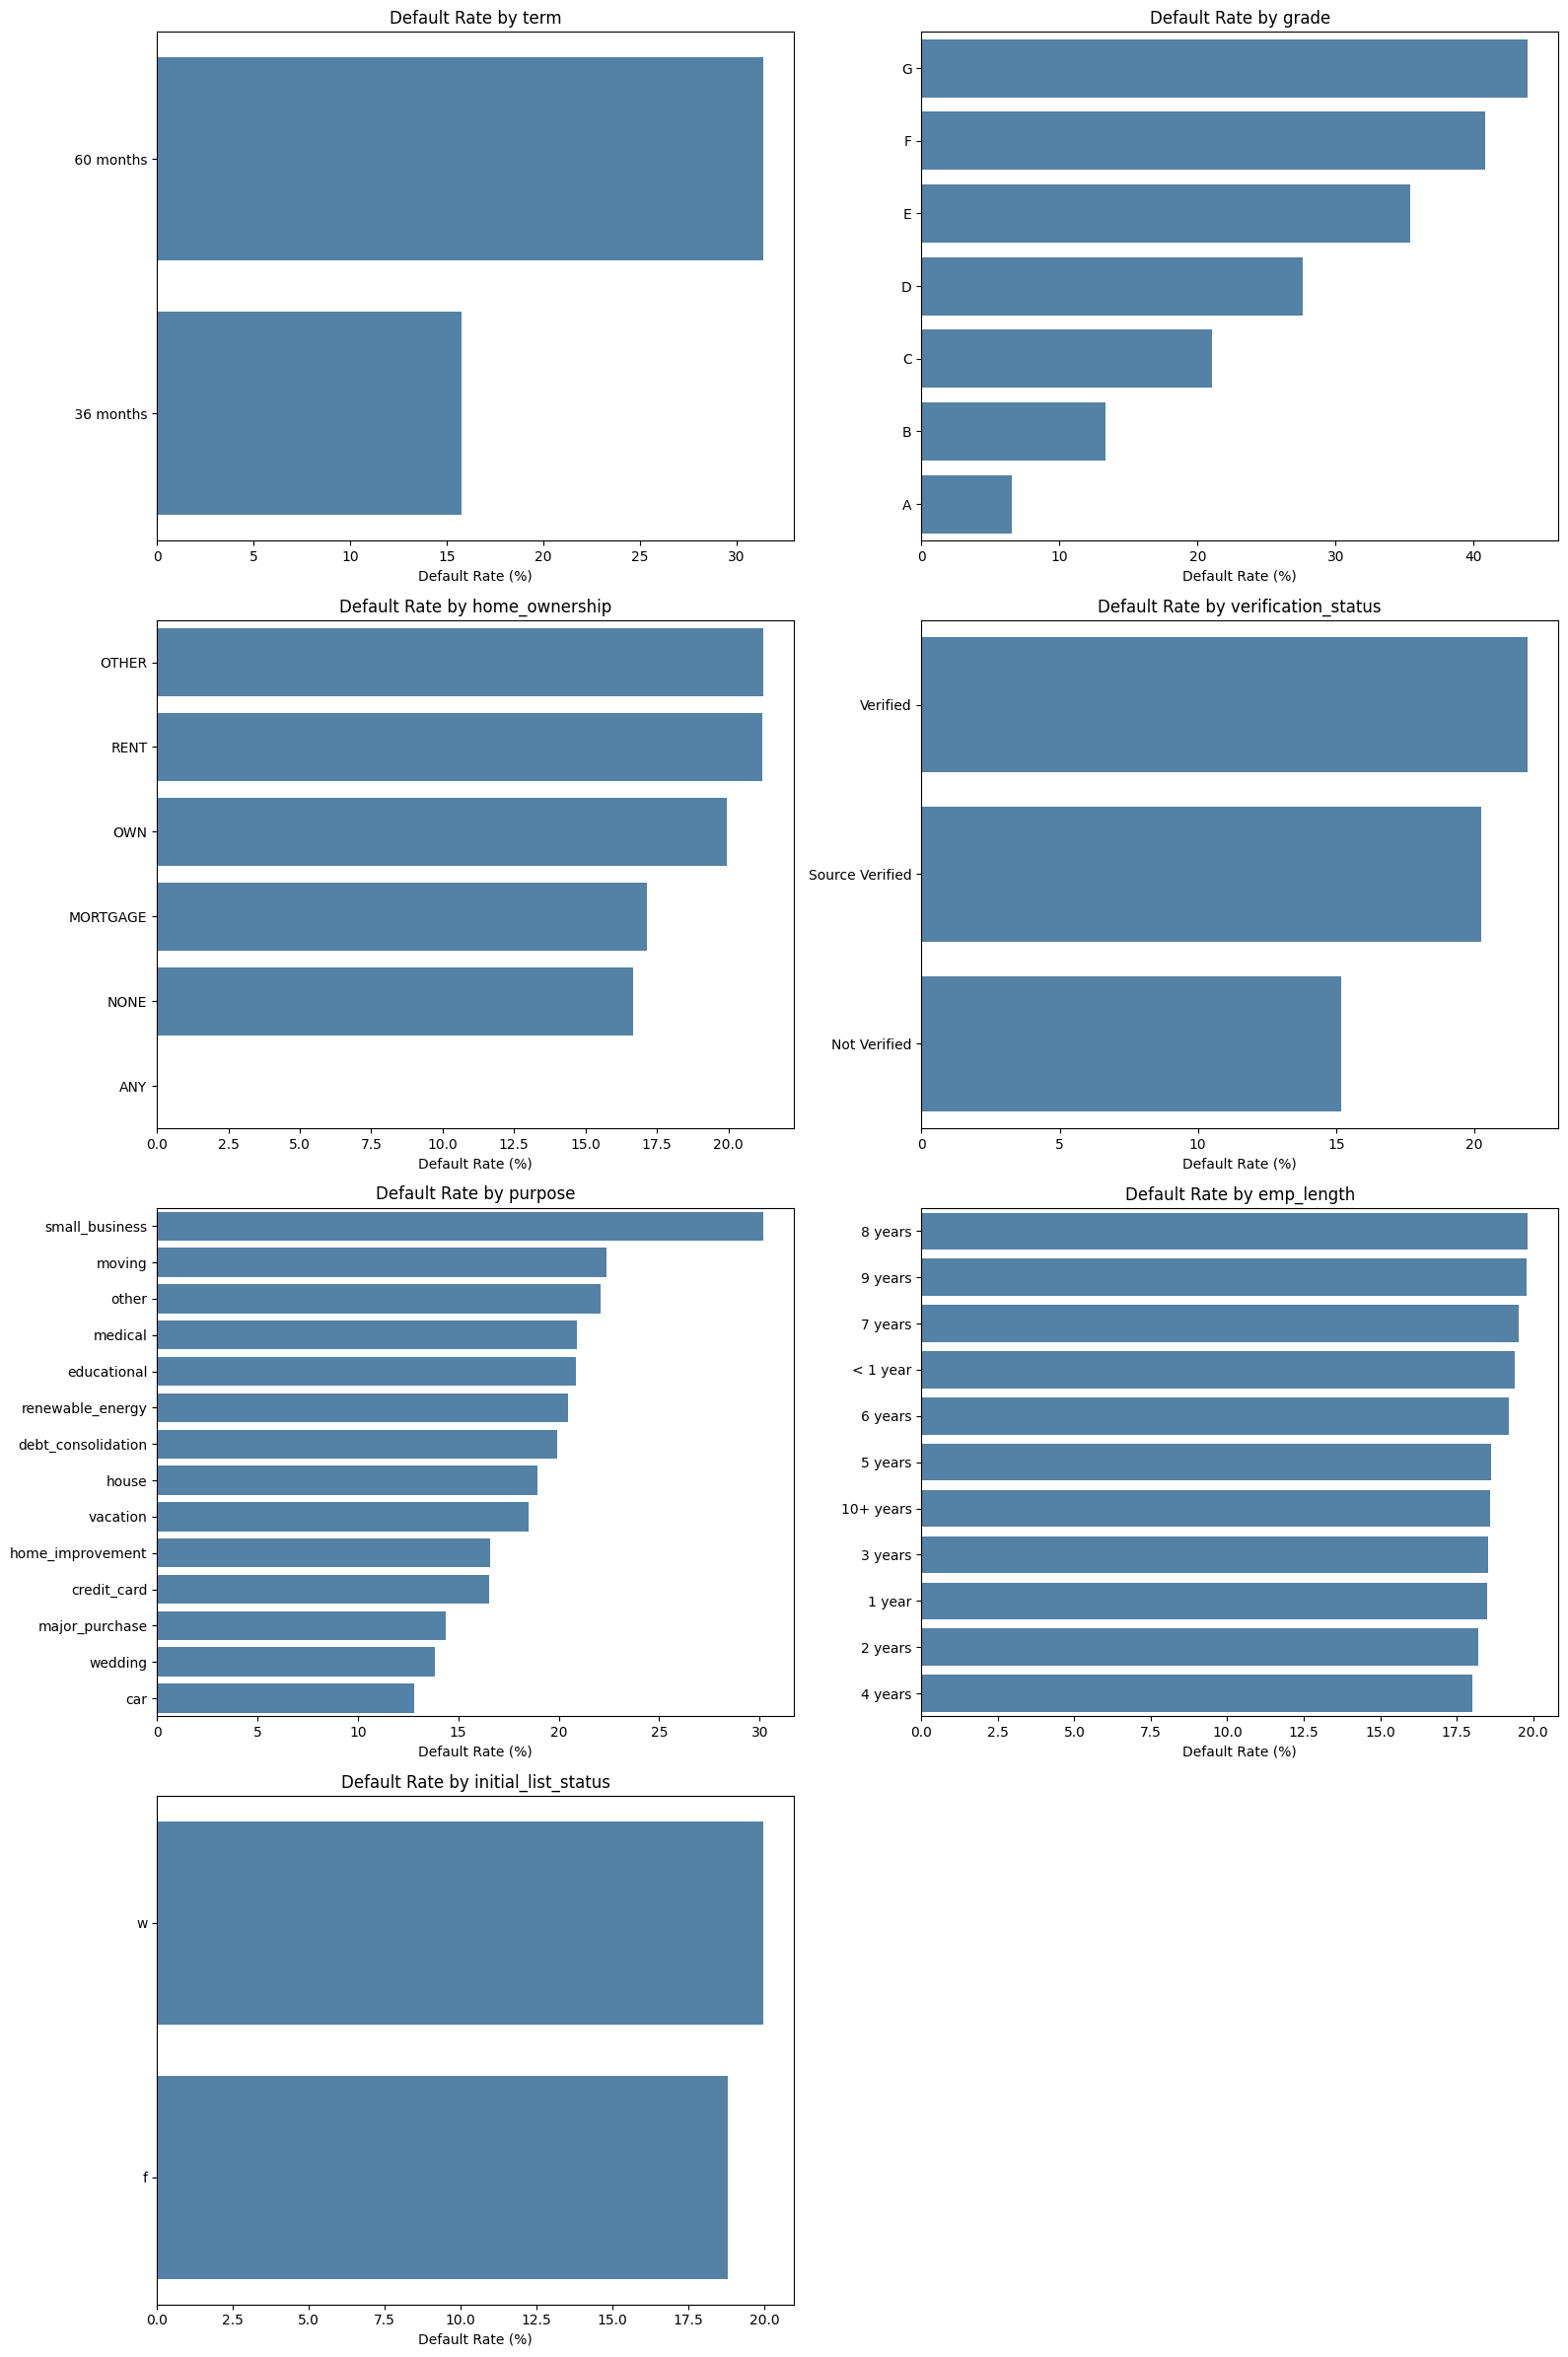

In [27]:
# Select key categorical features for default rate analysis
cat_bivariate_features = [
    'term', 'grade', 'home_ownership', 'verification_status',
    'purpose', 'emp_length', 'initial_list_status'
]

# Filter resolved loans only
df_resolved = df[df['loan_group'].isin(['Good Loan', 'Bad Loan'])].copy()
df_resolved['is_default'] = (df_resolved['loan_group'] == 'Bad Loan').astype(int)

# Grid 4x2
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 24))
axes = axes.flatten()

for i, col in enumerate(cat_bivariate_features):
    # Default rate per category
    default_rate = df_resolved.groupby(col)['is_default'].mean() * 100
    # Sort by default rate descending
    default_rate = default_rate.sort_values(ascending=False)

    sns.barplot(x=default_rate.values, y=default_rate.index,
                ax=axes[i], color='steelblue')
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_xlabel('Default Rate (%)')
    axes[i].set_ylabel('')

# Hide unused subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

#### Key Findings

**CODE_GENDER**
Male applicants have higher default rate (~10%) compared to female (~7%).
XNA shows near-zero default rate, needs to be handled before modeling.

**NAME_CONTRACT_TYPE**
Cash loans have higher default rate (~8%) compared to Revolving loans (~5%),
suggesting revolving loan applicants are relatively lower risk.

**NAME_INCOME_TYPE**
Maternity leave (~40%) and Unemployed (~37%) show extremely high default rates.
Pensioner and State servant are among the lowest risk groups.
Income type is a strong predictor of default risk.

**NAME_EDUCATION_TYPE**
Clear inverse relationship between education level and default risk.
Lower secondary has the highest default rate (~11%) while Academic degree has the lowest (~2%).

**OCCUPATION_TYPE**
Low-skill Laborers (~17%), Drivers and Waiters/Barmen staff (~13%) are highest risk.
Accountants and High-skill tech staff show the lowest risk (~4%).

**NAME_FAMILY_STATUS**
Civil marriage and Single applicants show the highest default rate (~10%).
Widow shows the lowest risk (~5%), suggesting age/stability factor.

**NAME_HOUSING_TYPE**
Rented apartment (~12%) and With parents (~11%) show higher default risk,
while Office apartment has the lowest (~6%).
Housing stability appears correlated with repayment behavior.

**WALLSMATERIAL_MODE**
Wooden (~10%) and Others (~9%) show higher default rates while
Monolithic shows the lowest (~4%). Moderate variation worth retaining.

---

# 6. Correlation Analysis

This section examines the linear relationship between numerical features and the target variable,
as well as multicollinearity between features. Results are used to identify the most relevant
features for modeling and detect redundant features that may need to be dropped.

The approach includes:
- **Heatmap** to visualize pairwise correlation between key numerical features
- **Point-Biserial Correlation** to rank feature correlation directly against TARGET

## 6.1 Heatmap


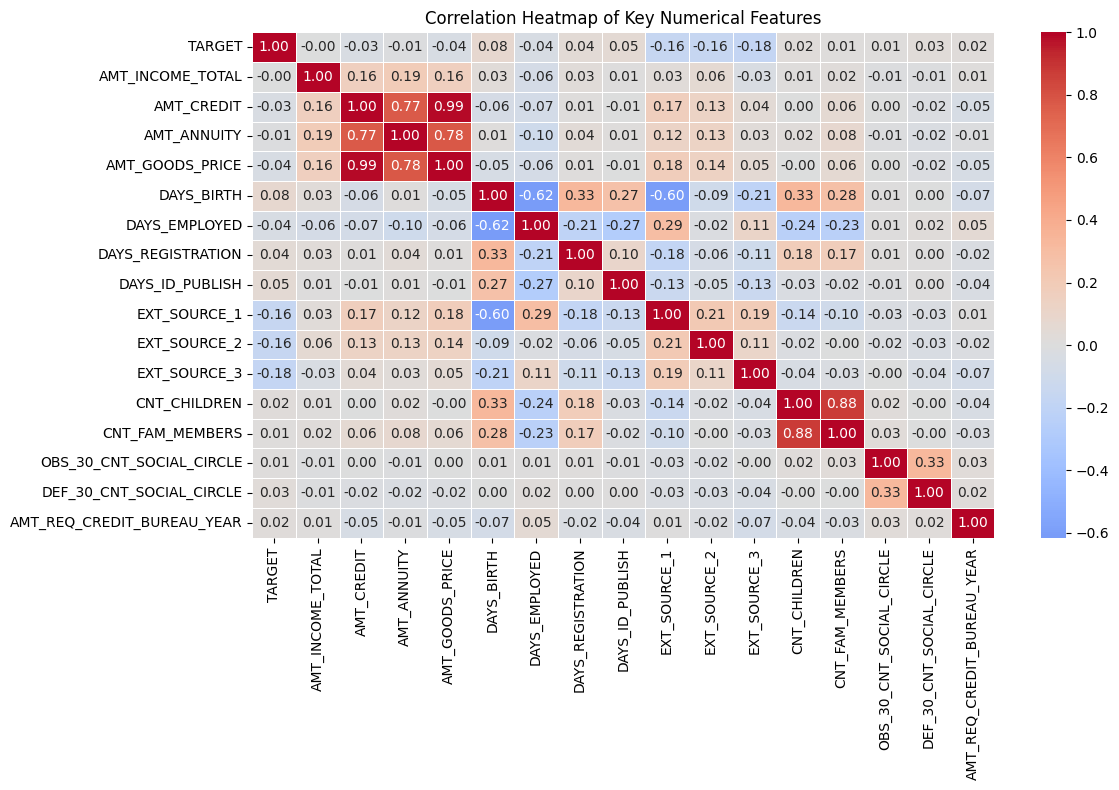

In [ ]:
# Select key numerical features for correlation analysis
corr_features = [
    'TARGET',
    # Financial features
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    # Days features
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
    # External credit scores — most discriminative
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    # Demographic
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS',
    # Social circle
    'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
    # Credit bureau enquiries
    'AMT_REQ_CREDIT_BUREAU_YEAR'
]

# Compute correlation matrix
corr_matrix = df_app_train[corr_features].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5
)
plt.title('Correlation Heatmap of Key Numerical Features')
plt.tight_layout()
plt.show()

#### Key Findings

**EXT_SOURCE features are the strongest predictors of TARGET**
`EXT_SOURCE_3` (-0.18), `EXT_SOURCE_2` (-0.16), and `EXT_SOURCE_1` (-0.16) show
the highest correlation with TARGET among all features, confirming findings from bivariate analysis.
Higher external score = lower default risk.

**DAYS_BIRTH has meaningful negative correlation with TARGET (-0.08)**
Older applicants (more negative DAYS_BIRTH) tend to have lower default risk,
consistent with findings in 4.2.1 and 4.2.2.

**High multicollinearity detected among financial features**
`AMT_CREDIT` and `AMT_GOODS_PRICE` are almost perfectly correlated (0.99),
and `AMT_ANNUITY` is also highly correlated with both (0.77-0.78).
Consider dropping one of these groups to reduce redundancy during feature selection.

**DAYS_BIRTH and DAYS_EMPLOYED are highly correlated (-0.62)**
Older applicants tend to have longer employment history, which makes sense contextually.
Both should be retained but their shared information should be considered during modeling.

**CNT_CHILDREN and CNT_FAM_MEMBERS are highly correlated (0.88)**
Both measure family size from different angles. Consider retaining only one,
or engineering a derived feature such as `CNT_NON_CHILDREN = CNT_FAM_MEMBERS - CNT_CHILDREN`.

**OBS and DEF social circle features are moderately correlated (0.33)**
Expected since more observed defaults in social circle naturally correlates
with the number of observations. Both can be retained.

**AMT_INCOME_TOTAL shows near-zero correlation with TARGET (-0.00)**
Confirms finding from 4.2.2 that income alone is not a strong predictor of default risk.

## 6.2 Point-Biserial Correlation

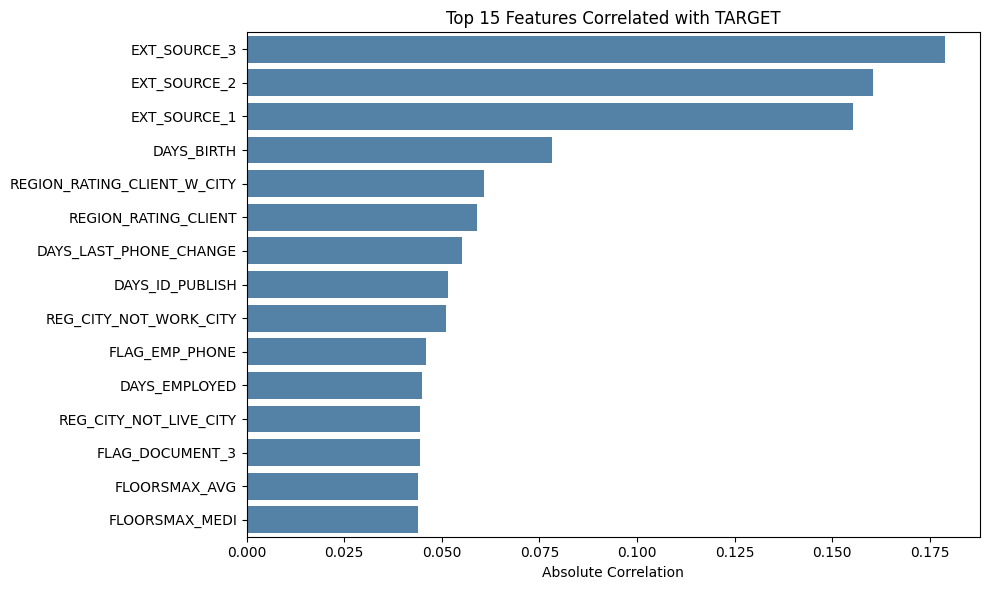

In [ ]:
# Compute correlation of all numerical features against TARGET
target_corr = (
    df_app_train.select_dtypes(include='number')
    .corr()['TARGET']
    .drop('TARGET')
    .abs()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr.values, y=target_corr.index, color='steelblue')
plt.title('Top 15 Features Correlated with TARGET')
plt.xlabel('Absolute Correlation')
plt.ylabel('')
plt.tight_layout()
plt.show()

#### Key Findings

**EXT_SOURCE dominates as top predictors**
`EXT_SOURCE_3` (0.18), `EXT_SOURCE_2` (0.16), and `EXT_SOURCE_1` (0.16) are
the three strongest features correlated with TARGET, confirming all previous analyses.

**DAYS_BIRTH is the strongest non-EXT_SOURCE predictor (0.08)**
Age remains a meaningful predictor, consistent with findings in 4.2.1 and 4.2.2.

**Region rating features appear in top 10**
`REGION_RATING_CLIENT_W_CITY` and `REGION_RATING_CLIENT` both show moderate correlation (~0.06),
suggesting the region where a client lives carries some default risk signal.

**Days features cluster in mid-range**
`DAYS_LAST_PHONE_CHANGE`, `DAYS_ID_PUBLISH`, and `DAYS_EMPLOYED` all appear in top 15,
confirming that temporal features are collectively informative despite individually moderate correlations.

**Address mismatch flags show signal**
`REG_CITY_NOT_WORK_CITY` and `REG_CITY_NOT_LIVE_CITY` appear in top 15,
suggesting applicants whose registered address does not match work or living address
may carry higher default risk.

**Overall correlations are low across all features**
Even the strongest feature (`EXT_SOURCE_3`) has absolute correlation of only ~0.18,
indicating no single feature is strongly predictive on its own.
**This confirms the need for a combination of features in modeling.**

---

# 7. Overall Insights & Recommendations

## Key Predictors Identified
- `EXT_SOURCE_1/2/3` are the strongest predictors of default risk across all analyses
- `DAYS_BIRTH` confirms younger applicants carry higher default risk
- `NAME_INCOME_TYPE` and `OCCUPATION_TYPE` show strong default rate differences across categories
- `REGION_RATING_CLIENT` and address mismatch flags carry moderate but meaningful signal

## Data Quality Issues to Address
- `DAYS_EMPLOYED` value of 365,243 is an encoding error, requires special handling
- `CODE_GENDER` XNA (4 rows) and `NAME_FAMILY_STATUS` Unknown (2 rows) need to be replaced with mode
- `NAME_INCOME_TYPE` rare categories (Maternity leave, Student, Businessman) should be grouped
- `AMT_INCOME_TOTAL` has extreme outlier at 117,000,000, needs capping

## Feature Engineering Recommendations
- Convert `DAYS_BIRTH`, `DAYS_EMPLOYED` to absolute values or age in years
- Derive `HAS_CAR` flag from `FLAG_OWN_CAR` as domain-aware imputation for `OWN_CAR_AGE`
- Derive `CNT_NON_CHILDREN = CNT_FAM_MEMBERS - CNT_CHILDREN` to reduce redundancy
- Consider grouping rare categories in `OCCUPATION_TYPE` and `ORGANIZATION_TYPE`

## Feature Selection Recommendations
- **Drop**: `FLAG_MOBIL`, `FLAG_CONT_MOBILE` (near-constant), `HOUSETYPE_MODE`, `EMERGENCYSTATE_MODE` (near-constant)
- **Drop or consolidate**: `AMT_GOODS_PRICE` (0.99 corr with `AMT_CREDIT`), `CNT_FAM_MEMBERS` (0.88 corr with `CNT_CHILDREN`)
- **Retain only `_AVG`** per building property group, drop `_MODE` and `_MEDI` variants
- **Retain `_MISSING` indicators** for features with high missing rates as they carry predictive signal

## Modeling Considerations
- Dataset is heavily imbalanced (8% default), requires oversampling, undersampling, or class weighting
- No single feature is strongly predictive on its own (max correlation ~0.18), combination of features is essential
- Tree-based models (XGBoost, LightGBM) may handle multicollinearity and missing values better than linear models


---

In [ ]:
# Read markdown cells from notebook
import json

with open('EDA_application_train.ipynb', 'r', encoding='utf-8') as f:
    nb = json.load(f)

for i, cell in enumerate(nb['cells']):
    if cell['cell_type'] == 'markdown':
        print(f"--- Cell {i} ---")
        print(''.join(cell['source']))
        print()

--- Cell 0 ---
# Exploratory Data Analysis (EDA)
## Dataset: application_train

**Author:** Oknardo Tulung  
**LinkedIn:** https://www.linkedin.com/in/oknardo-tulung/ 
**GitHub:** https://github.com/oknardo/Home_Credit_Scorecard_Model

---

## 📌 Project Overview
This project focuses on performing a comprehensive Exploratory Data Analysis (EDA) on the `application_train` dataset from the Home Credit risk modeling case. The goal is to understand the underlying patterns, data quality, and key drivers related to loan default behavior.

---

## 🎯 Objectives
- Understand the structure and characteristics of the dataset  
- Identify data quality issues (missing values, outliers, inconsistencies)  
- Analyze the distribution of key variables  
- Explore relationships between features and the target variable (loan default)  
- Generate initial insights to support feature engineering and modeling  

---

## 🔍 Analysis Scope
The analysis includes:
- Missing Value Analysis
- Univariate analysis (d